# 2.0 Full EIP-7999 Three-Resource Equilibrium

This notebook combines the independent isoelastic demand curves with the EIP-7999 metering anchors and the induced BAL model to solve a three-resource equilibrium fee vector.

The central mechanism assumptions are:

- a fixed 90M data-gas limit, with data targets of $1/6$, $1/5$, $1/4$, $1/3$, and $1/2$ of the limit;
- execution limits from 250M through 600M in 50M increments, with execution targets at one half of the limit;
- a 75M state-gas target and no state-gas limit;
- the 35-day independent isoelastic estimates centrally, with 21-, 60-, and 75-day estimates as robustness checks;
- the calibrated EIP-8038 + EIP-2780 execution multiplier and EIP-8037 state multiplier used in the Glamsterdam analysis;
- the full-7999 static-data multiplier from notebook 1.11; and
- EIP-8279 runtime BAL induced by state and execution/access activity, with $w_{\mathrm{state}}=0.113932$, $w_{\mathrm{execution}}=0.886068$, $\gamma_{\mathrm{BAL}}=0$, and $\rho_A=1$.

The main capacity combinations preserve the observed full-7999 metered data/execution ratio. A separate capacity grid crosses every execution limit with every data target to show what happens when the two capacities are imbalanced. This notebook solves the reserve-free equilibrium. Reserve-dominated equilibria are deferred until a blob-fee path or reserve scenario is specified.

In [1]:
from itertools import product
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from basefee.eip7999_normalized import (
    ResourceFeeConfig,
    compute_base_fee,
    excess_gas_for_base_fee,
)

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_BASE_FEE_WEI = 1
RESOURCES = ["execution", "data", "state"]

ACCOUNTING_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
EXECUTION_REPRICING_DAILY_CSV = DATA_DIR / f"execution_repricing_daily_{DATE_LABEL}.csv"
BAL_RUNTIME_CARD_CSV = DATA_DIR / f"bal_runtime_8279_parameter_card_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
G0_HEADLINE_CSV = DATA_DIR / f"three_way_equilibrium_headline_{DATE_LABEL}.csv"

OUT_CAPACITY_CSV = DATA_DIR / f"full_7999_equilibrium_capacity_card_{DATE_LABEL}.csv"
OUT_ACCOUNTING_CSV = DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
OUT_DATA_BRIDGE_CSV = DATA_DIR / f"full_7999_data_metering_bridge_{DATE_LABEL}.csv"
OUT_BAL_DRIVER_CSV = DATA_DIR / f"full_7999_bal_driver_calibration_{DATE_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"full_7999_equilibrium_results_{DATE_LABEL}.csv"
OUT_HEADLINE_CSV = DATA_DIR / f"full_7999_equilibrium_headline_{DATE_LABEL}.csv"
OUT_WINDOW_CSV = DATA_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.csv"
OUT_GRID_CSV = DATA_DIR / f"full_7999_equilibrium_capacity_grid_{DATE_LABEL}.csv"
OUT_MATCHED_CAPACITY_CSV = DATA_DIR / f"full_7999_empirical_matched_capacity_{DATE_LABEL}.csv"
OUT_DEMAND_ADEQUACY_CSV = DATA_DIR / f"full_7999_execution_demand_adequacy_{DATE_LABEL}.csv"
GRID_PLOT = PLOTS_DIR / f"full_7999_equilibrium_capacity_grid_{DATE_LABEL}.png"
BOUNDARY_PLOT = PLOTS_DIR / f"full_7999_data_equilibrium_boundary_{DATE_LABEL}.png"
WINDOW_PLOT = PLOTS_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.png"



## Capacity design

The 90M data-gas limit is a scenario input stated in protocol-metered gas. It is not a physical payload limit. In particular, EIP-8279 runtime bytes are transaction-local meter entries and need not equal the final BAL RLP bytes propagated with the block.

The data target is varied from one sixth to one half of the 90M metered limit. Execution has a separate 250M--600M limit sweep, with its target fixed at one half of each limit. State has a 75M target and no hard limit. A physical propagation constraint would require a separate mapping from metered static data and runtime BAL to bytes transmitted on the network.

In [2]:
EXECUTION_LIMITS = [value * 1_000_000 for value in range(250, 601, 50)]
DATA_GAS_LIMIT = 90_000_000
DATA_TARGET_DENOMINATORS = [6, 5, 4, 3, 2]
STATE_TARGET = 75_000_000
EXECUTION_TARGET_RATIO = 2
DATA_GAS_PER_BYTE = 16

capacity_card = pd.DataFrame([{
    'data_gas_limit': DATA_GAS_LIMIT,
    'data_target_denominators': ','.join(map(str, DATA_TARGET_DENOMINATORS)),
    'execution_gas_limit_min': min(EXECUTION_LIMITS),
    'execution_gas_limit_max': max(EXECUTION_LIMITS),
    'execution_limit_step': 50_000_000,
    'execution_target_ratio': EXECUTION_TARGET_RATIO,
    'state_gas_target': STATE_TARGET,
    'data_limit_interpretation': (
        'protocol-metered data gas scenario input; not physical payload bytes'
    ),
}])
capacity_card.to_csv(OUT_CAPACITY_CSV, index=False)
display(capacity_card.T)

,0
data_gas_limit,90000000
data_target_denominators,"6,5,4,3,2"
execution_gas_limit_min,250000000
execution_gas_limit_max,600000000
execution_limit_step,50000000
execution_target_ratio,2
state_gas_target,75000000
data_limit_interpretation,protocol-metered data gas scenario input; not ...


## 120-Day Demand And Metering Anchor

The demand elasticities were estimated using three historical gas-equivalent quantities. To transport those curves into 7999, the same physical activity is converted into each candidate resource's gas units.

For each resource, let $q_i^0$ be its historical gas-equivalent quantity and let $m_i$ convert that quantity into 7999 gas. The metered anchor is $g_i^0=m_iq_i^0$. A reference 7999 fee of $p_i^0=b_{\mathrm{ref}}/m_i$ preserves the historical effective price of that activity.

The [current EIP-7999 draft](https://eips.ethereum.org/EIPS/eip-7999) removes the EIP-7623 floor but retains calldata tokens, equivalent to 4 gas per zero byte and 16 per nonzero byte. This project's broader 8131/8279-style bandwidth scenario, specified in the [demand-model plan](../markdowns/demand_model_plan.md), instead meters every encoded byte at 16 gas and adds access-list, authorization-tuple, blob-hash, and eventually BAL bytes. The accounting bridge below reports both definitions so that the extension is not mistaken for the base EIP.

The static-data bridge uses exact Xatu calldata and blob-hash counts plus the existing sampled access-list and authorization-list calibrations. It does not make new RPC calls. BAL bytes are excluded from this metering multiplier because they are not independently demanded data. Their priced anchor is the EIP-8279 runtime counter estimated in notebook 1.11; the equilibrium adds that anchor as induced output of execution/access and state activity.

In [3]:
accounting = pd.read_csv(ACCOUNTING_PANEL_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[
    ["date", "data_gas_current", "eip7623_data_uplift_proxy"]
]
execution_repricing = pd.read_csv(EXECUTION_REPRICING_DAILY_CSV)[[
    "date", "execution_current", "execution_8038_2780_refund_corrected",
]]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
accounting = accounting.merge(
    execution_repricing, on="date", how="left", validate="one_to_one"
)
required = [
    "data_gas_current", "eip7623_data_uplift_proxy", "execution_current",
    "execution_8038_2780_refund_corrected",
]
if accounting[required].isna().any().any():
    raise ValueError("A data or execution repricing input is missing")
if not np.allclose(
    accounting["data_gas_current"],
    accounting["standard_calldata_gas"] + accounting["eip7623_data_uplift_proxy"],
):
    raise ValueError("Current data gas does not reconcile to standard calldata gas plus EIP-7623 uplift")

blocks = float(accounting["block_count"].sum())
BASE_FEE_REF = float(accounting["median_base_fee_per_gas"].median())
current_data_total = float(accounting["data_gas_current"].sum())
current_state_total = float(accounting["current_state_creation_gas_calibrated"].sum())
current_execution_total = float(
    accounting["current_gas_used"].sum() - current_data_total - current_state_total
)
if not np.allclose(accounting["execution_current"].sum(), current_execution_total, rtol=1e-10, atol=1):
    raise ValueError("Execution repricing denominator does not match the three-resource anchor")

execution_7999_total = float(accounting["execution_8038_2780_refund_corrected"].sum())
data_base_7999_total = float(accounting["standard_calldata_gas"].sum())
data_flat16_calldata_total = float(16 * accounting["calldata_bytes"].sum())
data_blob_hash_total = float(16 * accounting["blob_versioned_hash_bytes"].sum())
data_access_list_total = float(16 * accounting["cal_tx_access_list_bytes"].sum())
data_authorization_total = float(16 * accounting["cal_authorization_tuple_8131_bytes"].sum())
data_7999_no_bal_total = (
    data_flat16_calldata_total + data_blob_hash_total
    + data_access_list_total + data_authorization_total
)
if not np.isclose(
    data_7999_no_bal_total, accounting["bandwidth_gas_16_calibrated_no_bal"].sum()
):
    raise ValueError("No-BAL bandwidth components do not reconcile")
bal_runtime_card = pd.read_csv(BAL_RUNTIME_CARD_CSV)
if len(bal_runtime_card) != 1:
    raise ValueError("EIP-8279 runtime BAL parameter card must contain one row")
bal_runtime = bal_runtime_card.iloc[0]
bal_7999_gas_per_block = float(bal_runtime["bal_runtime_data_gas_per_block_at_16"])
bal_7999_total = bal_7999_gas_per_block * blocks
data_7999_with_bal_total = data_7999_no_bal_total + bal_7999_total
state_7999_total = float(accounting["state_gas_8037_calibrated"].sum())
BAL_EXECUTION_GAS_RATIO = bal_7999_total / current_execution_total
BAL_BYTES_PER_MILLION_EXECUTION_GAS = BAL_EXECUTION_GAS_RATIO / DATA_GAS_PER_BYTE * 1_000_000

BAL_STATE_RUNTIME_WEIGHT = float(bal_runtime["state_linked_runtime_weight_8279"])
BAL_EXECUTION_RUNTIME_WEIGHT = float(bal_runtime["execution_linked_runtime_weight_8279"])
if not np.isclose(BAL_STATE_RUNTIME_WEIGHT + BAL_EXECUTION_RUNTIME_WEIGHT, 1):
    raise ValueError("Two-way runtime BAL weights do not sum to one")
BAL_DATA_PRICE_ELASTICITY = float(bal_runtime["central_gamma_bal_data_price"])
BAL_ACCESS_RHO = float(bal_runtime["central_rho_access_execution_proxy"])
if BAL_DATA_PRICE_ELASTICITY != 0:
    raise ValueError("Central BAL model requires gamma_BAL=0")
bal_driver_card = pd.DataFrame([{
    "anchor_days": len(accounting),
    "anchor_blocks": blocks,
    "bal_gas_per_block": bal_7999_total / blocks,
    "historical_execution_gas_per_block": current_execution_total / blocks,
    "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
    "bal_bytes_per_million_historical_execution_gas": BAL_BYTES_PER_MILLION_EXECUTION_GAS,
    "parent_driver": "execution quantity as access proxy plus state-linked runtime creation",
    "bal_state_runtime_weight": BAL_STATE_RUNTIME_WEIGHT,
    "bal_execution_runtime_weight": BAL_EXECUTION_RUNTIME_WEIGHT,
    "gamma_bal_data_price": BAL_DATA_PRICE_ELASTICITY,
    "rho_access_execution_proxy": BAL_ACCESS_RHO,
    "bal_runtime_anchor_blocks": int(bal_runtime["runtime_anchor_blocks"]),
    "state_coupling_status": "state-linked runtime bytes follow state creation; remaining bytes use access proxy",
}])
bal_driver_card.to_csv(OUT_BAL_DRIVER_CSV, index=False)
display(bal_driver_card.T)

bridge_specs = [
    ("current_eip7623", "current 4/16 calldata plus EIP-7623 floor uplift", current_data_total),
    ("base_eip7999_tx_data", "floor removed; calldata remains 4/16", data_base_7999_total),
    ("flat16_calldata", "project extension: all calldata bytes at 16 gas", data_flat16_calldata_total),
    ("plus_blob_hashes", "plus exact 32-byte blob versioned hashes", data_flat16_calldata_total + data_blob_hash_total),
    ("plus_access_lists", "plus sampled fixed access-list content bytes", data_flat16_calldata_total + data_blob_hash_total + data_access_list_total),
    ("plus_authorizations_no_bal", "plus existing sampled authorization-tuple calibration; static anchor", data_7999_no_bal_total),
    ("plus_runtime_metered_bal", "plus calibrated EIP-8279 runtime BAL gas; reconciliation only", data_7999_with_bal_total),
]
data_bridge = pd.DataFrame(bridge_specs, columns=["scenario", "definition", "total_data_gas"])
data_bridge["data_gas_per_block"] = data_bridge["total_data_gas"] / blocks
data_bridge["multiplier_vs_current_eip7623"] = data_bridge["total_data_gas"] / current_data_total
data_bridge["incremental_gas_per_block"] = data_bridge["total_data_gas"].diff() / blocks
data_bridge["static_anchor_no_bal"] = data_bridge["scenario"].eq("plus_authorizations_no_bal")
data_bridge.to_csv(OUT_DATA_BRIDGE_CSV, index=False)
display(data_bridge)

ANCHOR_QUANTITIES = {
    "execution": current_execution_total / blocks,
    "data": current_data_total / blocks,
    "state": current_state_total / blocks,
}
METERING_MULTIPLIERS = {
    "execution": execution_7999_total / current_execution_total,
    "data": data_7999_no_bal_total / current_data_total,
    "state": state_7999_total / current_state_total,
}
ANCHOR_METERED_GAS = {
    name: ANCHOR_QUANTITIES[name] * METERING_MULTIPLIERS[name]
    for name in RESOURCES
}
REFERENCE_FEES_WEI = {
    name: BASE_FEE_REF / METERING_MULTIPLIERS[name]
    for name in RESOURCES
}

accounting_card = pd.DataFrame([{
    "start_date": accounting["date"].min(),
    "end_date": accounting["date"].max(),
    "days": len(accounting),
    "blocks": blocks,
    "historical_base_fee_ref_gwei": BASE_FEE_REF / GWEI,
    "execution_historical_quantity_per_block": ANCHOR_QUANTITIES["execution"],
    "data_historical_quantity_per_block": ANCHOR_QUANTITIES["data"],
    "state_historical_quantity_per_block": ANCHOR_QUANTITIES["state"],
    "execution_7999_gas_per_block": ANCHOR_METERED_GAS["execution"],
    "data_base_eip7999_4_16_per_block": data_base_7999_total / blocks,
    "data_flat16_calldata_per_block": data_flat16_calldata_total / blocks,
    "data_blob_hash_gas_per_block": data_blob_hash_total / blocks,
    "data_access_list_gas_per_block": data_access_list_total / blocks,
    "data_authorization_gas_per_block": data_authorization_total / blocks,
    "data_7999_gas_no_bal_per_block": data_7999_no_bal_total / blocks,
    "bal_7999_gas_per_block": bal_7999_total / blocks,
    "data_7999_gas_with_bal_per_block": data_7999_with_bal_total / blocks,
    "state_7999_gas_per_block": ANCHOR_METERED_GAS["state"],
    "execution_metering_multiplier": METERING_MULTIPLIERS["execution"],
    "data_metering_multiplier_no_bal": METERING_MULTIPLIERS["data"],
    "data_metering_multiplier_with_bal": data_7999_with_bal_total / current_data_total,
    "state_metering_multiplier": METERING_MULTIPLIERS["state"],
    "bal_share_of_data_gas_with_bal": bal_7999_total / data_7999_with_bal_total,
    "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
    "bal_bytes_per_million_historical_execution_gas": BAL_BYTES_PER_MILLION_EXECUTION_GAS,
    "bal_state_runtime_weight": BAL_STATE_RUNTIME_WEIGHT,
    "bal_execution_runtime_weight": BAL_EXECUTION_RUNTIME_WEIGHT,
    "bal_gamma_central": BAL_DATA_PRICE_ELASTICITY,
    "bal_access_rho_central": BAL_ACCESS_RHO,
    "bal_runtime_anchor_blocks": int(bal_runtime["runtime_anchor_blocks"]),
    "execution_reference_fee_gwei": REFERENCE_FEES_WEI["execution"] / GWEI,
    "data_reference_fee_gwei": REFERENCE_FEES_WEI["data"] / GWEI,
    "state_reference_fee_gwei": REFERENCE_FEES_WEI["state"] / GWEI,
}])
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(accounting_card.T)

# Preserve the observed full-7999 metered resource mix along the main comparison.
EMPIRICAL_DATA_EXECUTION_TARGET_RATIO = (
    data_7999_with_bal_total / execution_7999_total
)

matched_capacity_rows = []
for denominator in DATA_TARGET_DENOMINATORS:
    data_target = int(DATA_GAS_LIMIT // denominator)
    matched_execution_target = data_target / EMPIRICAL_DATA_EXECUTION_TARGET_RATIO
    matched_execution_limit = int(round(EXECUTION_TARGET_RATIO * matched_execution_target))
    matched_capacity_rows.append({
        'data_target_denominator': denominator,
        'data_target_ratio': 1 / denominator,
        'data_gas_limit': DATA_GAS_LIMIT,
        'data_gas_target': data_target,
        'empirical_data_execution_target_ratio': EMPIRICAL_DATA_EXECUTION_TARGET_RATIO,
        'matched_execution_gas_target': matched_execution_limit // EXECUTION_TARGET_RATIO,
        'matched_execution_gas_limit': matched_execution_limit,
        'within_250m_600m_execution_range': (
            min(EXECUTION_LIMITS) <= matched_execution_limit <= max(EXECUTION_LIMITS)
        ),
    })
matched_capacity_card = pd.DataFrame(matched_capacity_rows)
matched_capacity_card.to_csv(OUT_MATCHED_CAPACITY_CSV, index=False)

accounting_card['empirical_data_execution_target_ratio'] = (
    EMPIRICAL_DATA_EXECUTION_TARGET_RATIO
)
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(matched_capacity_card)


,0
anchor_days,120
anchor_blocks,"860,505.000000"
bal_gas_per_block,"1,919,099.891982"
historical_execution_gas_per_block,"23,942,241.363434"
bal_gas_per_historical_execution_gas,0.080155
bal_bytes_per_million_historical_execution_gas,"5,009.712392"
parent_driver,execution quantity as access proxy plus state-...
bal_state_runtime_weight,0.113932
bal_execution_runtime_weight,0.886068
gamma_bal_data_price,0.000000


,scenario,definition,total_data_gas,data_gas_per_block,multiplier_vs_current_eip7623,incremental_gas_per_block,static_anchor_no_bal
0,current_eip7623,current 4/16 calldata plus EIP-7623 floor uplift,"1,015,873,534,534.000000","1,180,555.063055",1.000000,NaN,False
1,base_eip7999_tx_data,floor removed; calldata remains 4/16,"888,840,106,060.000000","1,032,928.461845",0.874952,"-147,626.601210",False
2,flat16_calldata,project extension: all calldata bytes at 16 gas,"1,728,593,461,888.000000","2,008,812.803979",1.701583,"975,884.342134",False
3,plus_blob_hashes,plus exact 32-byte blob versioned hashes,"1,730,180,416,128.000000","2,010,657.016668",1.703145,"1,844.212689",False
4,plus_access_lists,plus sampled fixed access-list content bytes,"1,809,281,359,201.515137","2,102,580.878904",1.781010,"91,923.862236",False
5,plus_authorizations_no_bal,plus existing sampled authorization-tuple cali...,"1,827,387,770,648.058838","2,123,622.489873",1.798834,"21,041.610969",True
6,plus_runtime_metered_bal,plus calibrated EIP-8279 runtime BAL gas; reco...,"3,478,782,823,197.819336","4,042,722.381855",3.424425,"1,919,099.891982",False


,0
start_date,2026-02-01
end_date,2026-05-31
days,120
blocks,"860,505.000000"
historical_base_fee_ref_gwei,0.106928
execution_historical_quantity_per_block,"23,942,241.363434"
data_historical_quantity_per_block,"1,180,555.063055"
state_historical_quantity_per_block,"5,244,154.703798"
execution_7999_gas_per_block,"36,820,725.629258"
data_base_eip7999_4_16_per_block,"1,032,928.461845"


,data_target_denominator,data_target_ratio,data_gas_limit,data_gas_target,empirical_data_execution_target_ratio,matched_execution_gas_target,matched_execution_gas_limit,within_250m_600m_execution_range
0,6,0.166667,90000000,15000000,0.109795,136618553,273237107,True
1,5,0.200000,90000000,18000000,0.109795,163942264,327884529,True
2,4,0.250000,90000000,22500000,0.109795,204927830,409855661,True
3,3,0.333333,90000000,30000000,0.109795,273237107,546474214,True
4,2,0.500000,90000000,45000000,0.109795,409855661,819711322,False


## Independent Isoelastic Elasticities

Notebook 1.8 recovers separate execution, data, and state elasticities from the clean 2025 gas-limit events. The 35-day estimates are central. All four available window lengths are retained here because the equilibrium fee can be very sensitive when an elasticity is small. No aggregate-plus-softmax result is used in this notebook.

In [4]:
elasticities = pd.read_csv(ELASTICITY_CSV).sort_values("window_days")
WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
CENTRAL_WINDOW = 35
if CENTRAL_WINDOW not in WINDOW_DAYS:
    raise ValueError("35-day elasticity calibration is missing")
if (elasticities[[f"eps_{name}" for name in RESOURCES]] <= 0).any().any():
    raise ValueError("All independent elasticities must be positive")
display(elasticities[[
    "window_days", "eps_agg", "eps_execution", "eps_data", "eps_state"
]])

,window_days,eps_agg,eps_execution,eps_data,eps_state
0,21,0.194893,0.117067,0.201790,0.478438
1,35,0.169292,0.121160,0.229476,0.334864
2,60,0.127086,0.081668,0.204691,0.279676
3,75,0.119173,0.078511,0.201391,0.253556


## Three-resource equilibrium

Execution and state retain separate isoelastic demand curves. For either independently demanded resource $i$,

$$
g_i(p_i)=g_i^0\left(\frac{p_i}{p_i^0}\right)^{-\epsilon_i},
\qquad
p_i^*=p_i^0\left(\frac{g_i^0}{T_i}\right)^{1/\epsilon_i}.
$$

BAL is induced by the equilibrium execution and state quantities:

$$
B^*=B_0\left[
w_{\mathrm{state}}\frac{T_S/m_S}{S_0}
+w_{\mathrm{execution}}
\left(\frac{T_E/m_E}{E_0}\right)^{\rho_A}
\right].
$$

The data equilibrium clears static data plus BAL:

$$
D_{\mathrm{static}}(p_D^*)+B^*=T_D.
$$

With $\gamma_{\mathrm{BAL}}=0$, a finite data equilibrium exists only when $B^*<T_D$. If it exists,

$$
p_D^*=p_D^0
\left(
\frac{g_{\mathrm{static}}^0}{T_D-B^*}
\right)^{1/\epsilon_D}.
$$

The notebook reports both the equilibrium fee and the nearest fee representable by the integer fake exponential. It separately flags targets that require an equilibrium fee below the one-wei protocol minimum. Those cases are mathematical extrapolations, not equilibria that the protocol can represent.

In [5]:
def resource_config(resource, execution_limit, data_target):
    if resource == 'execution':
        return ResourceFeeConfig(
            name=resource,
            gas_limit=int(execution_limit),
            gas_target=int(execution_limit // EXECUTION_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    if resource == 'data':
        return ResourceFeeConfig(
            name=resource,
            gas_limit=DATA_GAS_LIMIT,
            gas_target=int(data_target),
            min_base_fee=MIN_BASE_FEE_WEI,
            reserve_mode='none',
        )
    if resource == 'state':
        return ResourceFeeConfig(
            name=resource,
            gas_limit=None,
            gas_target=STATE_TARGET,
            normalization_denominator=STATE_TARGET,
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    raise ValueError(resource)


def metered_demand(base_fee_wei, *, anchor_metered_gas, reference_fee_wei, elasticity):
    return anchor_metered_gas * (base_fee_wei / reference_fee_wei) ** (-elasticity)


def nearest_protocol_fee(continuous_fee_wei, *, config, demand_fn):
    lower = max(MIN_BASE_FEE_WEI, math.floor(continuous_fee_wei))
    upper = max(MIN_BASE_FEE_WEI, math.ceil(continuous_fee_wei))
    candidates = []
    for requested_fee in sorted({lower, upper}):
        excess = excess_gas_for_base_fee(int(requested_fee), config)
        represented_fee = compute_base_fee(excess, config)
        usage = demand_fn(represented_fee)
        candidates.append({
            'protocol_base_fee_wei': represented_fee,
            'warm_start_excess_gas': excess,
            'metered_at_protocol_fee': usage,
            'absolute_target_error': abs(usage - config.gas_target),
        })
    return min(candidates, key=lambda row: row['absolute_target_error'])


def solve_resource(*, resource, elasticity, execution_limit, data_target):
    config = resource_config(resource, execution_limit, data_target)
    q0 = ANCHOR_QUANTITIES[resource]
    multiplier = METERING_MULTIPLIERS[resource]
    anchor_metered = q0 * multiplier
    reference_fee = BASE_FEE_REF / multiplier
    continuous_fee = reference_fee * (anchor_metered / config.gas_target) ** (1 / elasticity)

    def demand_fn(base_fee_wei):
        return metered_demand(
            base_fee_wei,
            anchor_metered_gas=anchor_metered,
            reference_fee_wei=reference_fee,
            elasticity=elasticity,
        )

    continuous_metered = demand_fn(continuous_fee)
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    demand_at_minimum_fee = demand_fn(MIN_BASE_FEE_WEI)
    protocol_target_reachable = demand_at_minimum_fee >= config.gas_target
    return {
        'resource': resource,
        'gas_limit': config.gas_limit,
        'gas_target': config.gas_target,
        'elasticity': elasticity,
        'anchor_historical_quantity': q0,
        'metering_multiplier': multiplier,
        'anchor_metered_gas': anchor_metered,
        'target_to_metered_anchor_ratio': config.gas_target / anchor_metered,
        'reference_base_fee_gwei': reference_fee / GWEI,
        'equilibrium_base_fee_wei_continuous': continuous_fee,
        'equilibrium_base_fee_gwei': continuous_fee / GWEI,
        'effective_equilibrium_fee_gwei': multiplier * continuous_fee / GWEI,
        'metered_at_continuous_fee': continuous_metered,
        'continuous_target_error_pct': 100 * (continuous_metered / config.gas_target - 1),
        'minimum_fee_binding': continuous_fee < MIN_BASE_FEE_WEI,
        'demand_at_minimum_fee': demand_at_minimum_fee,
        'demand_shortfall_at_minimum_fee': max(config.gas_target - demand_at_minimum_fee, 0),
        'protocol_target_reachable': protocol_target_reachable,
        'protocol_base_fee_wei': protocol['protocol_base_fee_wei'],
        'protocol_base_fee_gwei': protocol['protocol_base_fee_wei'] / GWEI,
        'protocol_fee_at_minimum': protocol['protocol_base_fee_wei'] == MIN_BASE_FEE_WEI,
        'warm_start_excess_gas': protocol['warm_start_excess_gas'],
        'metered_at_protocol_fee': protocol['metered_at_protocol_fee'],
        'protocol_target_error_pct': 100 * (protocol['metered_at_protocol_fee'] / config.gas_target - 1),
        'equilibrium_exists': True,
        'infeasible_reason': None,
    }


def solve_coupled_data(*, static_elasticity, execution_target, state_target,
                       execution_limit, data_target):
    config = resource_config('data', execution_limit, data_target)
    static_anchor = ANCHOR_METERED_GAS['data']
    bal_anchor = bal_7999_total / blocks
    reference_fee = REFERENCE_FEES_WEI['data']
    execution_physical = execution_target / METERING_MULTIPLIERS['execution']
    execution_ratio = execution_physical / ANCHOR_QUANTITIES['execution']
    state_physical = state_target / METERING_MULTIPLIERS['state']
    state_ratio = state_physical / ANCHOR_QUANTITIES['state']
    access_proxy_ratio = execution_ratio ** BAL_ACCESS_RHO
    bal_parent_activity_ratio = (
        BAL_EXECUTION_RUNTIME_WEIGHT * access_proxy_ratio
        + BAL_STATE_RUNTIME_WEIGHT * state_ratio
    )
    induced_bal = bal_anchor * bal_parent_activity_ratio
    target_margin = config.gas_target - induced_bal

    common = {
        'execution_physical_quantity_driver': execution_physical,
        'execution_access_proxy_ratio_to_anchor': execution_ratio,
        'execution_physical_ratio_to_anchor': execution_ratio,
        'state_physical_quantity_driver': state_physical,
        'state_physical_ratio_to_anchor': state_ratio,
        'bal_parent_activity_ratio': bal_parent_activity_ratio,
        'bal_state_runtime_weight': BAL_STATE_RUNTIME_WEIGHT,
        'bal_execution_runtime_weight': BAL_EXECUTION_RUNTIME_WEIGHT,
        'rho_access_execution_proxy': BAL_ACCESS_RHO,
        'bal_price_elasticity': BAL_DATA_PRICE_ELASTICITY,
        'bal_gas_per_historical_execution_gas': BAL_EXECUTION_GAS_RATIO,
        'bal_target_margin_gas': target_margin,
        'bal_target_margin_pct': target_margin / config.gas_target,
        'bal_alone_exceeds_target': induced_bal >= config.gas_target,
        'bal_parent_driver': 'execution_quantity_as_access_proxy_plus_state_linked_runtime_creation',
    }

    if induced_bal >= config.gas_target:
        return {
            'resource': 'data',
            'gas_limit': config.gas_limit,
            'gas_target': config.gas_target,
            'elasticity': static_elasticity,
            'anchor_historical_quantity': ANCHOR_QUANTITIES['data'],
            'metering_multiplier': METERING_MULTIPLIERS['data'],
            'anchor_metered_gas': static_anchor,
            'target_to_metered_anchor_ratio': config.gas_target / static_anchor,
            'reference_base_fee_gwei': reference_fee / GWEI,
            'equilibrium_base_fee_wei_continuous': np.nan,
            'equilibrium_base_fee_gwei': np.nan,
            'effective_equilibrium_fee_gwei': np.nan,
            'metered_at_continuous_fee': induced_bal,
            'continuous_target_error_pct': 100 * (induced_bal / config.gas_target - 1),
            'minimum_fee_binding': False,
            'demand_at_minimum_fee': np.nan,
            'demand_shortfall_at_minimum_fee': np.nan,
            'protocol_target_reachable': False,
            'protocol_base_fee_wei': np.nan,
            'protocol_base_fee_gwei': np.nan,
            'protocol_fee_at_minimum': False,
            'warm_start_excess_gas': np.nan,
            'metered_at_protocol_fee': np.nan,
            'protocol_target_error_pct': np.nan,
            'static_data_gas_at_equilibrium': 0.0,
            'bal_data_gas_at_equilibrium': induced_bal,
            'bal_share_of_data_target': induced_bal / config.gas_target,
            **common,
            'equilibrium_exists': False,
            'infeasible_reason': 'induced BAL gas reaches data target at gamma_BAL=0',
        }

    continuous_fee = reference_fee * (static_anchor / target_margin) ** (1 / static_elasticity)

    def components(base_fee_wei):
        static_gas = static_anchor * (base_fee_wei / reference_fee) ** (-static_elasticity)
        return static_gas, induced_bal, static_gas + induced_bal

    def demand_fn(base_fee_wei):
        return components(base_fee_wei)[2]

    static_gas, bal_gas, total_gas = components(continuous_fee)
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    demand_at_minimum_fee = demand_fn(MIN_BASE_FEE_WEI)
    protocol_target_reachable = demand_at_minimum_fee >= config.gas_target
    return {
        'resource': 'data',
        'gas_limit': config.gas_limit,
        'gas_target': config.gas_target,
        'elasticity': static_elasticity,
        'anchor_historical_quantity': ANCHOR_QUANTITIES['data'],
        'metering_multiplier': METERING_MULTIPLIERS['data'],
        'anchor_metered_gas': static_anchor,
        'target_to_metered_anchor_ratio': config.gas_target / static_anchor,
        'reference_base_fee_gwei': reference_fee / GWEI,
        'equilibrium_base_fee_wei_continuous': continuous_fee,
        'equilibrium_base_fee_gwei': continuous_fee / GWEI,
        'effective_equilibrium_fee_gwei': METERING_MULTIPLIERS['data'] * continuous_fee / GWEI,
        'metered_at_continuous_fee': total_gas,
        'continuous_target_error_pct': 100 * (total_gas / config.gas_target - 1),
        'minimum_fee_binding': continuous_fee < MIN_BASE_FEE_WEI,
        'demand_at_minimum_fee': demand_at_minimum_fee,
        'demand_shortfall_at_minimum_fee': max(config.gas_target - demand_at_minimum_fee, 0),
        'protocol_target_reachable': protocol_target_reachable,
        'protocol_base_fee_wei': protocol['protocol_base_fee_wei'],
        'protocol_base_fee_gwei': protocol['protocol_base_fee_wei'] / GWEI,
        'protocol_fee_at_minimum': protocol['protocol_base_fee_wei'] == MIN_BASE_FEE_WEI,
        'warm_start_excess_gas': protocol['warm_start_excess_gas'],
        'metered_at_protocol_fee': protocol['metered_at_protocol_fee'],
        'protocol_target_error_pct': 100 * (protocol['metered_at_protocol_fee'] / config.gas_target - 1),
        'static_data_gas_at_equilibrium': static_gas,
        'bal_data_gas_at_equilibrium': bal_gas,
        'bal_share_of_data_target': bal_gas / config.gas_target,
        **common,
        'equilibrium_exists': True,
        'infeasible_reason': None,
    }


grid_specs = []
for execution_limit, denominator in product(EXECUTION_LIMITS, DATA_TARGET_DENOMINATORS):
    grid_specs.append({
        'scenario_family': 'off_path_grid',
        'scenario': f'grid_E{execution_limit // 1_000_000}_D90_T1of{denominator}_S75',
        'execution_gas_limit': int(execution_limit),
        'data_gas_limit': DATA_GAS_LIMIT,
        'data_target_denominator': int(denominator),
        'data_gas_target': int(DATA_GAS_LIMIT // denominator),
        'empirically_matched': False,
    })

matched_specs = []
for row in matched_capacity_card.itertuples(index=False):
    if not row.within_250m_600m_execution_range:
        continue
    matched_specs.append({
        'scenario_family': 'empirical_matched',
        'scenario': (
            f'matched_E{row.matched_execution_gas_limit / 1_000_000:.1f}'
            f'_D90_T1of{row.data_target_denominator}_S75'
        ),
        'execution_gas_limit': int(row.matched_execution_gas_limit),
        'data_gas_limit': DATA_GAS_LIMIT,
        'data_target_denominator': int(row.data_target_denominator),
        'data_gas_target': int(row.data_gas_target),
        'empirically_matched': True,
    })

scenario_specs = pd.DataFrame([*grid_specs, *matched_specs])
rows = []
for _, calibration in elasticities.iterrows():
    window_days = int(calibration['window_days'])
    for spec in scenario_specs.itertuples(index=False):
        execution_row = solve_resource(
            resource='execution',
            elasticity=float(calibration['eps_execution']),
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        state_row = solve_resource(
            resource='state',
            elasticity=float(calibration['eps_state']),
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        data_row = solve_coupled_data(
            static_elasticity=float(calibration['eps_data']),
            execution_target=execution_row['gas_target'],
            state_target=state_row['gas_target'],
            execution_limit=spec.execution_gas_limit,
            data_target=spec.data_gas_target,
        )
        for result in [execution_row, data_row, state_row]:
            result.update({
                'scenario_family': spec.scenario_family,
                'scenario': spec.scenario,
                'empirically_matched': spec.empirically_matched,
                'window_days': window_days,
                'execution_gas_limit': spec.execution_gas_limit,
                'execution_gas_target': spec.execution_gas_limit // EXECUTION_TARGET_RATIO,
                'data_gas_limit': spec.data_gas_limit,
                'data_target_denominator': spec.data_target_denominator,
                'data_target_ratio': 1 / spec.data_target_denominator,
                'data_gas_target': spec.data_gas_target,
                'state_gas_target': STATE_TARGET,
                'empirical_data_execution_target_ratio': EMPIRICAL_DATA_EXECUTION_TARGET_RATIO,
                'execution_metering_source': '120_day_total_ratio_8038_2780_refund_corrected',
                'data_metering_scenario': 'static_flat16_plus_induced_runtime_bal_gamma0_access_proxy',
            })
            rows.append(result)

results = pd.DataFrame(rows)
feasible_results = results[results['equilibrium_exists']]
if not np.allclose(
    feasible_results['metered_at_continuous_fee'],
    feasible_results['gas_target'],
    rtol=1e-10,
):
    raise AssertionError('Continuous equilibrium does not clear every feasible resource target')

for window_days in WINDOW_DAYS:
    check = results[results['window_days'].eq(window_days)]
    execution_check = check[check['resource'].eq('execution')]
    if execution_check.groupby('execution_gas_limit')['equilibrium_base_fee_gwei'].nunique().max() != 1:
        raise AssertionError('Execution fee should not depend on the data target')
    if check[check['resource'].eq('state')]['equilibrium_base_fee_gwei'].nunique() != 1:
        raise AssertionError('State fee should not depend on execution or data targets')

results.to_csv(OUT_RESULTS_CSV, index=False)
central_grid = results[
    results['window_days'].eq(CENTRAL_WINDOW)
    & results['scenario_family'].eq('off_path_grid')
].copy()
central_grid.to_csv(OUT_GRID_CSV, index=False)
print('solved', results.shape, 'resource equilibria')
print('scenario specifications:', len(scenario_specs))
print('no data equilibrium:', int((~results['equilibrium_exists']).sum()))
print('equilibrium fees below one wei:', int(results['minimum_fee_binding'].sum()))
print('protocol-unreachable targets at one wei:', int((~results['protocol_target_reachable']).sum()))

solved (528, 58) resource equilibria
scenario specifications: 44
no data equilibrium: 0
equilibrium fees below one wei: 66
protocol-unreachable targets at one wei: 66


## Empirically anchored capacity scenarios

The main scenarios preserve the observed full-7999 metered ratio

$$
\kappa_0
=\frac{g_{D,\mathrm{static}}^0+B_0}{g_E^0}
=0.1098.
$$

For each data target, the matched execution target is $T_E=T_D/\kappa_0$ and the execution limit is $2T_E$. The $1/6$, $1/5$, $1/4$, and $1/3$ data targets imply execution limits inside the requested 250M--600M range. Matching the $1/2$ data target would require approximately 820M execution gas, so it is excluded from the main comparison and retained only in the full capacity grid.

These are equilibrium calculations, not forecasts that builders will immediately fill the targets. The demand-adequacy diagnostics below identify when the isoelastic solution requires fees near or below the one-wei minimum.

In [6]:
central = results[
    results['window_days'].eq(CENTRAL_WINDOW)
    & results['scenario_family'].eq('empirical_matched')
].copy()

index_columns = [
    'scenario', 'scenario_family', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_limit', 'data_gas_target', 'data_target_denominator',
    'state_gas_target', 'empirical_data_execution_target_ratio',
]
fee_wide = central.pivot(
    index=index_columns, columns='resource', values='equilibrium_base_fee_gwei'
).reset_index().rename(columns={
    'execution': 'execution_target_clearing_fee_gwei_continuous',
    'data': 'data_target_clearing_fee_gwei_continuous',
    'state': 'state_target_clearing_fee_gwei_continuous',
})
protocol_wide = central.pivot(
    index='scenario', columns='resource', values='protocol_base_fee_wei'
).reset_index().rename(columns={
    'execution': 'execution_protocol_base_fee_wei',
    'data': 'data_protocol_base_fee_wei',
    'state': 'state_protocol_base_fee_wei',
})
reachable_wide = central.pivot(
    index='scenario', columns='resource', values='protocol_target_reachable'
).reset_index().rename(columns={
    'execution': 'execution_target_reachable_at_one_wei',
    'data': 'data_target_reachable_at_one_wei',
    'state': 'state_target_reachable_at_one_wei',
})

headline = (
    fee_wide
    .merge(protocol_wide, on='scenario', validate='one_to_one')
    .merge(reachable_wide, on='scenario', validate='one_to_one')
)
data_components = central[central['resource'].eq('data')][[
    'scenario', 'static_data_gas_at_equilibrium', 'bal_data_gas_at_equilibrium',
    'bal_share_of_data_target', 'bal_target_margin_gas', 'bal_target_margin_pct',
    'execution_access_proxy_ratio_to_anchor', 'state_physical_ratio_to_anchor',
    'bal_parent_activity_ratio', 'bal_state_runtime_weight',
    'bal_execution_runtime_weight',
]]
execution_components = central[central['resource'].eq('execution')][[
    'scenario', 'target_to_metered_anchor_ratio', 'demand_at_minimum_fee',
    'demand_shortfall_at_minimum_fee', 'minimum_fee_binding',
]].rename(columns={
    'target_to_metered_anchor_ratio': 'execution_target_to_metered_anchor_ratio',
    'demand_at_minimum_fee': 'execution_demand_at_one_wei',
    'demand_shortfall_at_minimum_fee': 'execution_demand_shortfall_at_one_wei',
    'minimum_fee_binding': 'execution_continuous_fee_below_one_wei',
})
headline = (
    headline
    .merge(data_components, on='scenario', validate='one_to_one')
    .merge(execution_components, on='scenario', validate='one_to_one')
    .sort_values('data_gas_target')
)
headline.to_csv(OUT_HEADLINE_CSV, index=False)
display(headline[[
    'scenario', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_limit', 'data_gas_target', 'state_gas_target',
    'execution_target_clearing_fee_gwei_continuous',
    'data_target_clearing_fee_gwei_continuous',
    'state_target_clearing_fee_gwei_continuous',
    'execution_protocol_base_fee_wei', 'data_protocol_base_fee_wei',
    'state_protocol_base_fee_wei', 'bal_data_gas_at_equilibrium',
    'bal_share_of_data_target', 'execution_target_to_metered_anchor_ratio',
    'execution_target_reachable_at_one_wei',
]])

,scenario,execution_gas_limit,execution_gas_target,data_gas_limit,data_gas_target,state_gas_target,execution_target_clearing_fee_gwei_continuous,data_target_clearing_fee_gwei_continuous,state_target_clearing_fee_gwei_continuous,execution_protocol_base_fee_wei,data_protocol_base_fee_wei,state_protocol_base_fee_wei,bal_data_gas_at_equilibrium,bal_share_of_data_target,execution_target_to_metered_anchor_ratio,execution_target_reachable_at_one_wei
0,matched_E273.2_D90_T1of6_S75,273237107,136618553,90000000,15000000,75000000,0.000001,0.000170,0.001184,1388,170470,1184471,"6,862,147.499955",0.457476,3.710371,True
1,matched_E327.9_D90_T1of5_S75,327884529,163942264,90000000,18000000,75000000,0.000000,0.000073,0.001184,308,73331,1184471,"8,124,010.487363",0.451334,4.452445,True
2,matched_E409.9_D90_T1of4_S75,409855661,204927830,90000000,22500000,75000000,0.000000,0.000026,0.001184,49,26418,1184471,"10,016,804.945382",0.445191,5.565557,True
3,matched_E546.5_D90_T1of3_S75,546474214,273237107,90000000,30000000,75000000,0.000000,0.000007,0.001184,5,7188,1184471,"13,171,462.390809",0.439049,7.420742,True


## Capacity grid, feasibility boundary, and event-window sensitivity

The full capacity grid crosses eight execution limits with five data targets while holding the data limit at 90M and the state target at 75M. It tests capacity combinations rather than selecting an optimal design.

The first figure shows the 35-day execution and data equilibrium fees and the share of each data target occupied by induced BAL. Star markers identify the four empirically paired execution/data scenarios.

The second figure plots the minimum data target implied by BAL, $T_D^{\min}(T_E)=B^*(T_E,T_S)$, with $T_S=75$M. At or below this boundary, no finite data equilibrium exists when $\gamma_{\mathrm{BAL}}=0$.

The third figure draws a separate line for each of the 21-, 35-, 60-, and 75-day elasticity estimates across the paired capacity scenarios. The 35-day central estimate is shown with the thickest line.

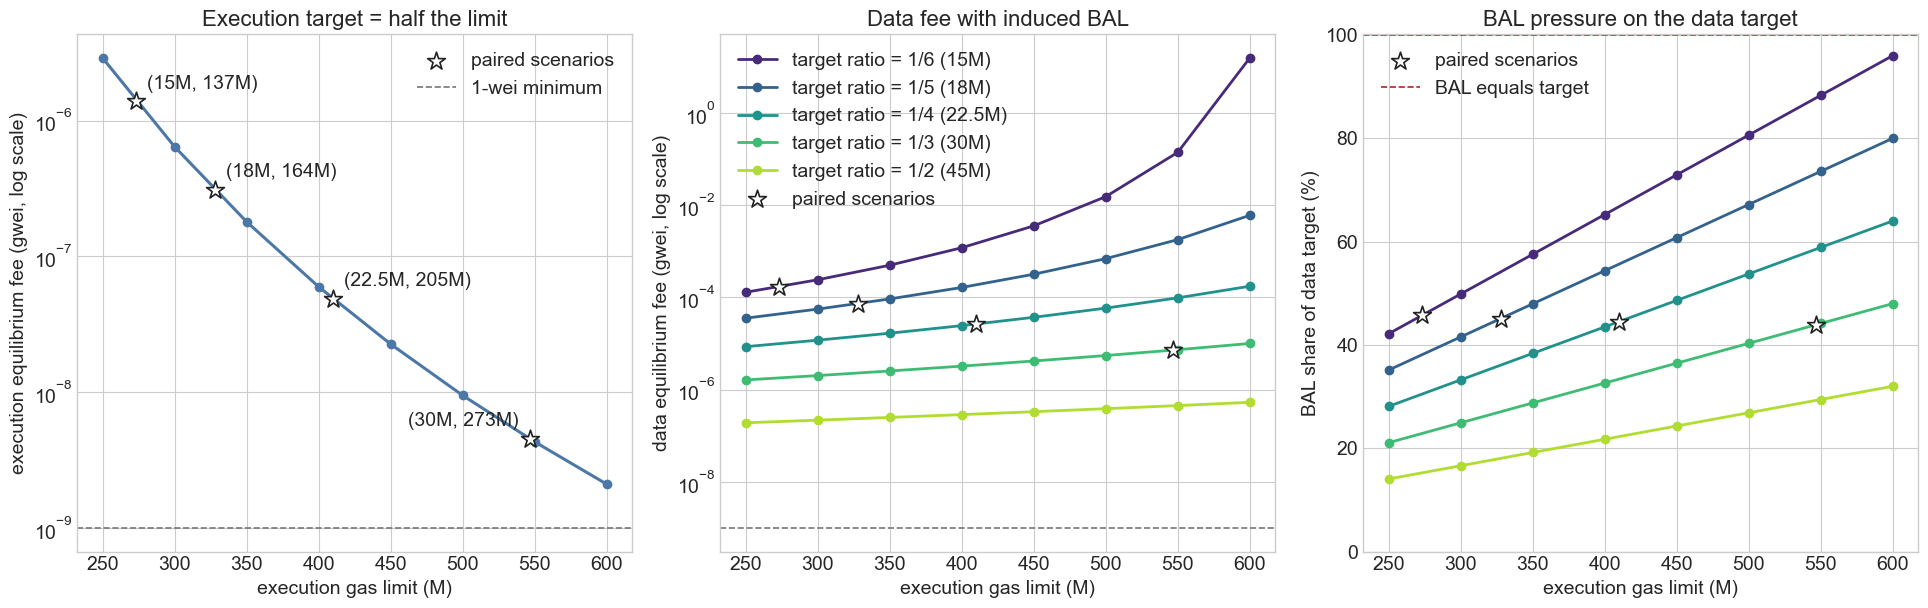

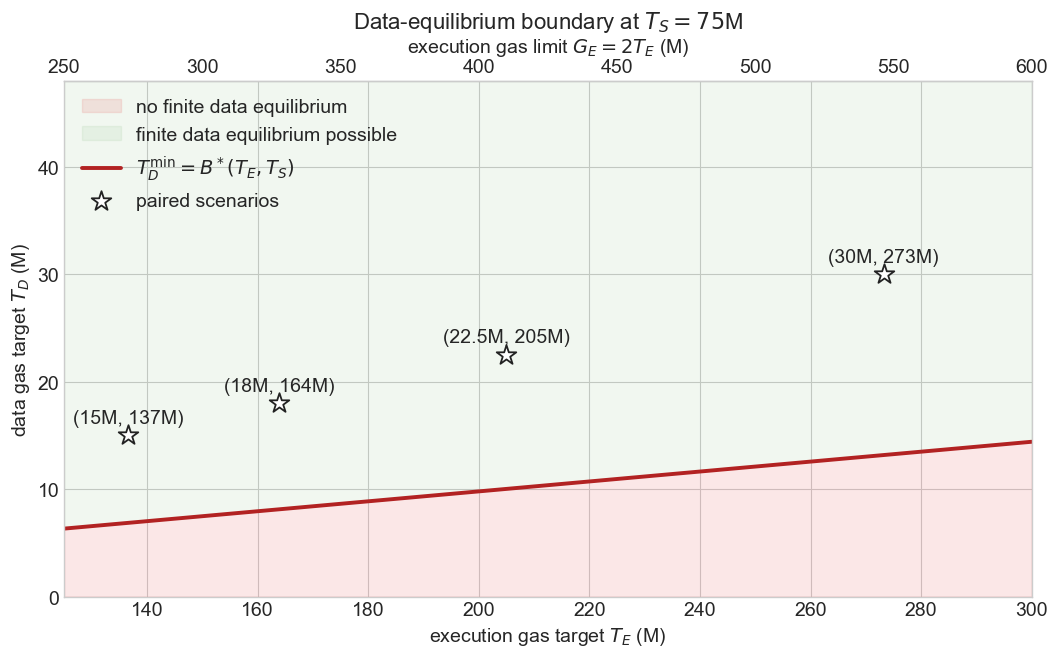

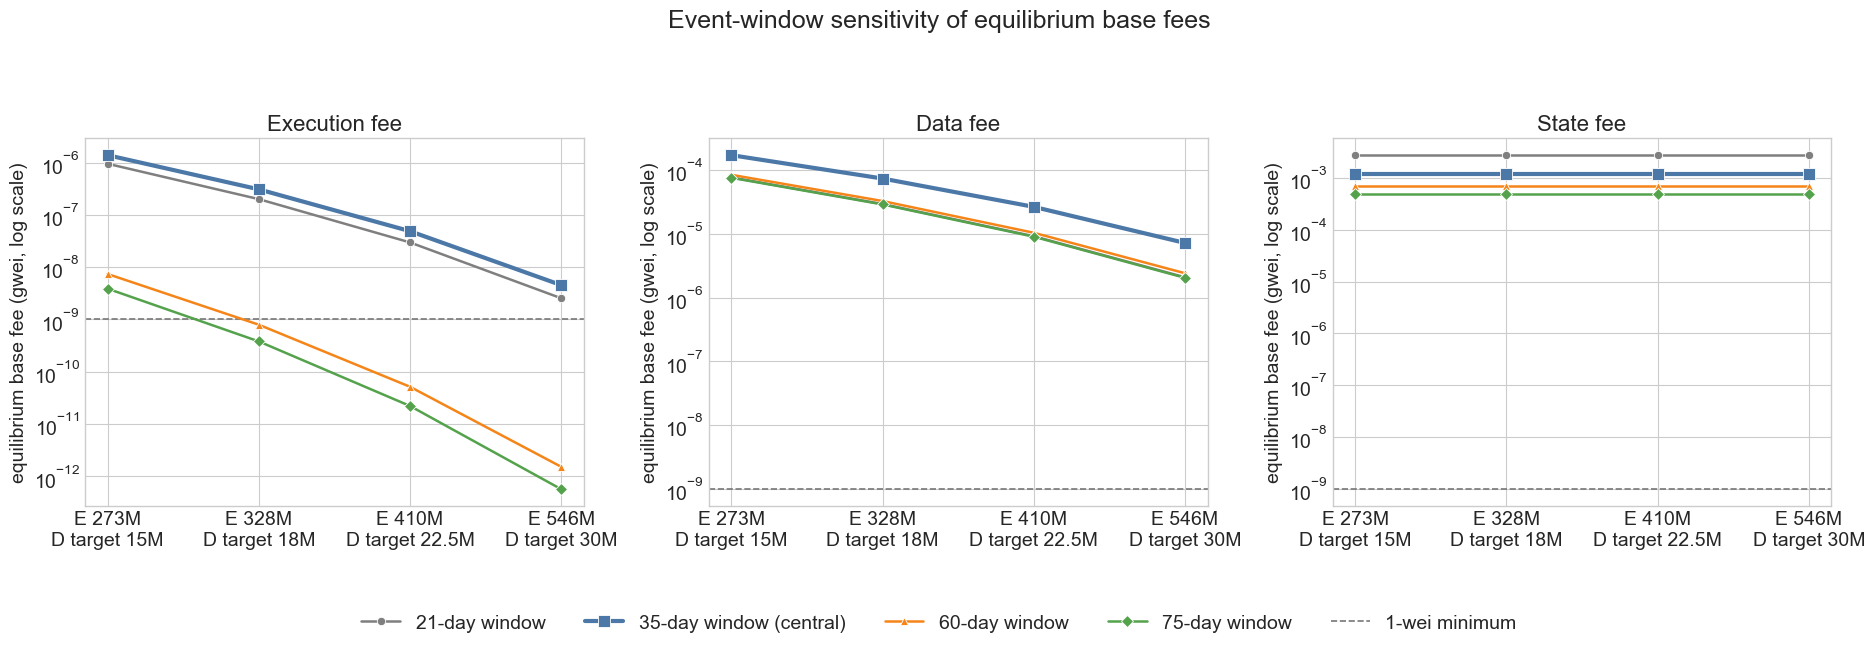

In [7]:
central_grid_execution = (
    central_grid[central_grid['resource'].eq('execution')]
    .sort_values('execution_gas_limit')
    .drop_duplicates('execution_gas_limit')
)
central_grid_data = central_grid[central_grid['resource'].eq('data')].copy()
paired_execution = (
    central[central['resource'].eq('execution')]
    .sort_values('execution_gas_limit')
)
paired_data = (
    central[central['resource'].eq('data')]
    .sort_values('execution_gas_limit')
)

fig, axes = plt.subplots(1, 3, figsize=(19.5, 6.3))
axes[0].plot(
    central_grid_execution['execution_gas_limit'] / 1e6,
    central_grid_execution['equilibrium_base_fee_gwei'],
    marker='o', color='#4C78A8', linewidth=2.2,
)
axes[0].scatter(
    paired_execution['execution_gas_limit'] / 1e6,
    paired_execution['equilibrium_base_fee_gwei'],
    marker='*', s=180, facecolor='white', edgecolor='#222222',
    linewidth=1.2, zorder=6, label='paired scenarios',
)
for index, row in enumerate(paired_execution.itertuples(index=False)):
    label = f'({row.data_gas_target / 1e6:g}M, {row.execution_gas_target / 1e6:.0f}M)'
    is_last = index == len(paired_execution) - 1
    axes[0].annotate(
        label,
        (row.execution_gas_limit / 1e6, row.equilibrium_base_fee_gwei),
        xytext=((-8 if is_last else 8), 9), textcoords='offset points',
        ha=('right' if is_last else 'left'), fontsize=14,
    )
axes[0].axhline(1 / GWEI, color='#777777', linestyle='--', linewidth=1.2, label='1-wei minimum')
axes[0].set_yscale('log')
axes[0].set_xlabel('execution gas limit (M)')
axes[0].set_ylabel('execution equilibrium fee (gwei, log scale)')
axes[0].set_title('Execution target = half the limit')
axes[0].legend(frameon=False)

colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(DATA_TARGET_DENOMINATORS)))
for color, denominator in zip(colors, DATA_TARGET_DENOMINATORS):
    subset = central_grid_data[
        central_grid_data['data_target_denominator'].eq(denominator)
    ].sort_values('execution_gas_limit')
    label = f'target ratio = 1/{denominator:g} ({subset.data_gas_target.iloc[0] / 1e6:g}M)'
    axes[1].plot(
        subset['execution_gas_limit'] / 1e6,
        subset['equilibrium_base_fee_gwei'],
        marker='o', color=color, linewidth=2, label=label,
    )
    axes[2].plot(
        subset['execution_gas_limit'] / 1e6,
        100 * subset['bal_share_of_data_target'],
        marker='o', color=color, linewidth=2, label=label,
    )
axes[1].scatter(
    paired_data['execution_gas_limit'] / 1e6,
    paired_data['equilibrium_base_fee_gwei'],
    marker='*', s=180, facecolor='white', edgecolor='#222222',
    linewidth=1.2, zorder=6, label='paired scenarios',
)
axes[2].scatter(
    paired_data['execution_gas_limit'] / 1e6,
    100 * paired_data['bal_share_of_data_target'],
    marker='*', s=180, facecolor='white', edgecolor='#222222',
    linewidth=1.2, zorder=6, label='paired scenarios',
)
axes[1].axhline(1 / GWEI, color='#777777', linestyle='--', linewidth=1.2)
axes[1].set_yscale('log')
axes[1].set_xlabel('execution gas limit (M)')
axes[1].set_ylabel('data equilibrium fee (gwei, log scale)')
axes[1].set_title('Data fee with induced BAL')
axes[1].legend(frameon=False, fontsize=14)
axes[2].axhline(100, color='#B22222', linestyle='--', linewidth=1.2, label='BAL equals target')
axes[2].set_xlabel('execution gas limit (M)')
axes[2].set_ylabel('BAL share of data target (%)')
axes[2].set_title('BAL pressure on the data target')
axes[2].set_ylim(bottom=0)
right_handles, right_labels = axes[2].get_legend_handles_labels()
right_legend = {label: handle for handle, label in zip(right_handles, right_labels)}
axes[2].legend(
    [right_legend['paired scenarios'], right_legend['BAL equals target']],
    ['paired scenarios', 'BAL equals target'],
    frameon=False, loc='upper left',
)
fig.tight_layout()
fig.savefig(GRID_PLOT, dpi=180, bbox_inches='tight')
plt.show()

execution_target_boundary = np.linspace(
    min(EXECUTION_LIMITS) / EXECUTION_TARGET_RATIO,
    max(EXECUTION_LIMITS) / EXECUTION_TARGET_RATIO,
    300,
)
execution_ratio_boundary = (
    execution_target_boundary / METERING_MULTIPLIERS['execution']
) / ANCHOR_QUANTITIES['execution']
state_ratio_boundary = (
    STATE_TARGET / METERING_MULTIPLIERS['state']
) / ANCHOR_QUANTITIES['state']
bal_boundary = (bal_7999_total / blocks) * (
    BAL_EXECUTION_RUNTIME_WEIGHT
    * execution_ratio_boundary ** BAL_ACCESS_RHO
    + BAL_STATE_RUNTIME_WEIGHT * state_ratio_boundary
)

boundary_x = execution_target_boundary / 1e6
boundary_y = bal_boundary / 1e6
boundary_ymax = 48
fig, ax = plt.subplots(figsize=(10.8, 6.8))
ax.fill_between(
    boundary_x, 0, boundary_y,
    color='#E45756', alpha=0.14, label='no finite data equilibrium',
)
ax.fill_between(
    boundary_x, boundary_y, boundary_ymax,
    color='#54A24B', alpha=0.08, label='finite data equilibrium possible',
)
ax.plot(
    boundary_x, boundary_y, color='#B22222', linewidth=2.8,
    label=r'$T_D^{\min}=B^*(T_E,T_S)$',
)
ax.scatter(
    paired_data['execution_gas_target'] / 1e6,
    paired_data['data_gas_target'] / 1e6,
    marker='*', s=220, facecolor='white', edgecolor='#222222',
    linewidth=1.3, zorder=6, label='paired scenarios',
)
for row in paired_data.itertuples(index=False):
    ax.annotate(
        f'({row.data_gas_target / 1e6:g}M, {row.execution_gas_target / 1e6:.0f}M)',
        (row.execution_gas_target / 1e6, row.data_gas_target / 1e6),
        xytext=(0, 9), textcoords='offset points', ha='center', fontsize=14,
    )
ax.set_xlim(boundary_x.min(), boundary_x.max())
ax.set_ylim(0, boundary_ymax)
ax.set_xlabel(r'execution gas target $T_E$ (M)')
ax.set_ylabel(r'data gas target $T_D$ (M)')
ax.set_title(r'Data-equilibrium boundary at $T_S=75$M')
secondary = ax.secondary_xaxis(
    'top', functions=(lambda target: 2 * target, lambda limit: limit / 2)
)
secondary.set_xlabel(r'execution gas limit $G_E=2T_E$ (M)')
ax.legend(frameon=False, loc='upper left', fontsize=14)
fig.tight_layout()
fig.savefig(BOUNDARY_PLOT, dpi=180, bbox_inches='tight')
plt.show()

window_rows = results[results['scenario_family'].eq('empirical_matched')].copy()
window_export_cols = [
    'scenario', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_limit', 'data_gas_target', 'data_target_denominator',
    'window_days', 'resource', 'gas_target', 'elasticity',
    'equilibrium_base_fee_wei_continuous', 'equilibrium_base_fee_gwei',
    'protocol_base_fee_wei', 'protocol_target_error_pct',
    'protocol_target_reachable', 'static_data_gas_at_equilibrium',
    'bal_data_gas_at_equilibrium', 'bal_share_of_data_target',
    'bal_target_margin_gas', 'execution_access_proxy_ratio_to_anchor',
]
window_rows[window_export_cols].sort_values(
    ['data_gas_target', 'window_days', 'resource']
).to_csv(OUT_WINDOW_CSV, index=False)

matched_order = (
    window_rows[['scenario', 'execution_gas_limit', 'data_gas_target']]
    .drop_duplicates()
    .sort_values('data_gas_target')
)
scenario_labels = [
    f'E {row.execution_gas_limit / 1e6:.0f}M\nD target {row.data_gas_target / 1e6:g}M'
    for row in matched_order.itertuples(index=False)
]
window_colors = {
    21: '#7F7F7F',
    35: '#4C78A8',
    60: '#F58518',
    75: '#54A24B',
}
window_markers = {21: 'o', 35: 's', 60: '^', 75: 'D'}

fig, axes = plt.subplots(1, 3, figsize=(19.0, 6.6), sharex=True)
x_positions = np.arange(len(matched_order))
for ax, resource in zip(axes, RESOURCES):
    resource_rows = window_rows[window_rows['resource'].eq(resource)]
    fee_by_window = (
        resource_rows.pivot(
            index='scenario', columns='window_days',
            values='equilibrium_base_fee_gwei',
        )
        .reindex(matched_order['scenario'])
    )
    for window_days in WINDOW_DAYS:
        is_central = window_days == CENTRAL_WINDOW
        ax.plot(
            x_positions,
            fee_by_window[window_days],
            color=window_colors[window_days],
            marker=window_markers[window_days],
            linewidth=3.0 if is_central else 1.8,
            markersize=8 if is_central else 6,
            markeredgecolor='white',
            markeredgewidth=0.6,
            label=(
                f'{window_days}-day window (central)'
                if is_central else f'{window_days}-day window'
            ),
            zorder=4 if is_central else 3,
        )
    ax.axhline(
        1 / GWEI, color='#777777', linestyle='--', linewidth=1.2,
        label='1-wei minimum',
    )
    ax.set_yscale('log')
    ax.set_xticks(x_positions, scenario_labels)
    ax.set_title(f'{resource.capitalize()} fee')
    ax.set_ylabel('equilibrium base fee (gwei, log scale)')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=5, frameon=False, fontsize=14,
)
fig.suptitle('Event-window sensitivity of equilibrium base fees', y=0.98)
fig.tight_layout(rect=(0, 0.13, 1, 0.92))
fig.savefig(WINDOW_PLOT, dpi=180, bbox_inches='tight')
plt.show()

## Demand adequacy and BAL pressure

The isoelastic equations produce a model-implied execution fee, but the protocol cannot charge less than one wei. If the equilibrium fee is below one wei, demand at the protocol minimum is still below the target. That is the clearest model-based warning that the proposed execution target may exceed demand under the estimated curve.

This is not a forecast that demand will fail to grow. It shows how far the capacity scenarios extrapolate from the observed anchor and where the protocol minimum prevents exact target clearing.

For data, the corresponding diagnostic is the remaining target space after induced BAL:

$$
T_D-B^*.
$$

The closer this margin is to zero, the more the data equilibrium is determined by BAL rather than static transaction data.

In [8]:
execution_adequacy = central_grid_execution[[
    'execution_gas_limit', 'execution_gas_target',
    'target_to_metered_anchor_ratio', 'equilibrium_base_fee_wei_continuous',
    'protocol_base_fee_wei', 'demand_at_minimum_fee',
    'demand_shortfall_at_minimum_fee', 'protocol_target_reachable',
]].sort_values('execution_gas_limit')
execution_adequacy.to_csv(OUT_DEMAND_ADEQUACY_CSV, index=False)
display(execution_adequacy)

matched_data = central[
    central['resource'].eq('data')
][[
    'scenario', 'execution_gas_limit', 'execution_gas_target',
    'data_gas_target', 'equilibrium_base_fee_gwei',
    'static_data_gas_at_equilibrium', 'bal_data_gas_at_equilibrium',
    'bal_share_of_data_target', 'bal_target_margin_gas',
    'equilibrium_exists', 'protocol_target_reachable',
]].sort_values('data_gas_target')
display(matched_data)

,execution_gas_limit,execution_gas_target,target_to_metered_anchor_ratio,equilibrium_base_fee_wei_continuous,protocol_base_fee_wei,demand_at_minimum_fee,demand_shortfall_at_minimum_fee,protocol_target_reachable
132,250000000,125000000,3.394827,"2,890.816397",2891,"328,281,194.052292",0.000000,True
159,300000000,150000000,4.073793,641.936780,642,"328,281,194.052292",0.000000,True
162,350000000,175000000,4.752758,179.863068,180,"328,281,194.052292",0.000000,True
186,400000000,200000000,5.431723,59.744948,60,"328,281,194.052292",0.000000,True
192,450000000,225000000,6.110689,22.600085,23,"328,281,194.052292",0.000000,True
219,500000000,250000000,6.789654,9.472121,9,"328,281,194.052292",0.000000,True
222,550000000,275000000,7.468620,4.313300,4,"328,281,194.052292",0.000000,True
246,600000000,300000000,8.147585,2.103386,2,"328,281,194.052292",0.000000,True


,scenario,execution_gas_limit,execution_gas_target,data_gas_target,equilibrium_base_fee_gwei,static_data_gas_at_equilibrium,bal_data_gas_at_equilibrium,bal_share_of_data_target,bal_target_margin_gas,equilibrium_exists,protocol_target_reachable
253,matched_E273.2_D90_T1of6_S75,273237107,136618553,15000000,0.000170,"8,137,852.500045","6,862,147.499955",0.457476,"8,137,852.500045",True,True
256,matched_E327.9_D90_T1of5_S75,327884529,163942264,18000000,0.000073,"9,875,989.512637","8,124,010.487363",0.451334,"9,875,989.512637",True,True
259,matched_E409.9_D90_T1of4_S75,409855661,204927830,22500000,0.000026,"12,483,195.054618","10,016,804.945382",0.445191,"12,483,195.054618",True,True
262,matched_E546.5_D90_T1of3_S75,546474214,273237107,30000000,0.000007,"16,828,537.609191","13,171,462.390809",0.439049,"16,828,537.609191",True,True


## Interpretation

- Full EIP-7999 has an equilibrium fee vector: execution and state clear independent targets, while the data fee clears static data plus BAL induced by the execution and state targets.
- The empirically anchored capacity combinations preserve the observed metered data/execution ratio. They form the main comparison; the full 8-by-5 grid tests imbalanced capacity choices.
- The 90M metered data limit is held fixed as a scenario input. It is not interpreted as a physical payload bound because runtime-metered BAL bytes differ from final BAL RLP bytes.
- With $\gamma_{\mathrm{BAL}}=0$, raising the data fee does not reduce BAL directly. High execution targets can therefore leave little room for static data when the data target is low.
- Execution limits up to 600M require substantial extrapolation from the observed execution anchor. Scenarios whose equilibrium execution fee falls below one wei cannot clear their target under the protocol minimum and should be interpreted as demand-adequacy warnings.
- The notebook solves the reserve-free equilibrium. Reserve-dominated equilibria require a specified blob-fee path or reserve scenario; limit hits, volatility, and shock recovery require the dynamic replay.